In [1]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (20, 10)

In [82]:
def adjust_gamma(image, gamma=1.0):
	# build a lookup table mapping the pixel values [0, 255] to
	# their adjusted gamma values
	invGamma = 1.0 / gamma
	table = np.array([((i / 255.0) ** invGamma) * 255
		for i in np.arange(0, 256)]).astype("uint8")
	# apply gamma correction using the lookup table
	return cv2.LUT(image, table)

In [87]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
    return images
imgs = load_images_from_folder("/home/nuru/git/nuru/tmp/depth_imgs_0/")
ref_frame = imgs[-1]
len(imgs)

79

In [117]:
diff_imgs = []
kernel = np.ones((20, 20), np.uint8)
for img in imgs:
    _, mask = cv2.threshold(np.abs(img.astype(np.int16) - ref_frame), 0, 255, cv2.THRESH_BINARY)
    mask = cv2.erode((mask).astype(np.uint8) / 100.0, kernel).astype("uint8")
#     print(np.min(mask), np.max(mask))
    ret, labels = cv2.connectedComponents(mask)
    print(labels)
    break
    # Map component labels to hue val
    label_hue = np.uint8(179*labels/np.max(labels))
    blank_ch = 255*np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])

    # cvt to BGR for display
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)

    # set bg label to black
    labeled_img[label_hue==0] = 0
    
    diff_imgs.append(labeled_img)
#     plt.imshow(labeled_img)
#     plt.show()
#     diff_imgs.append(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


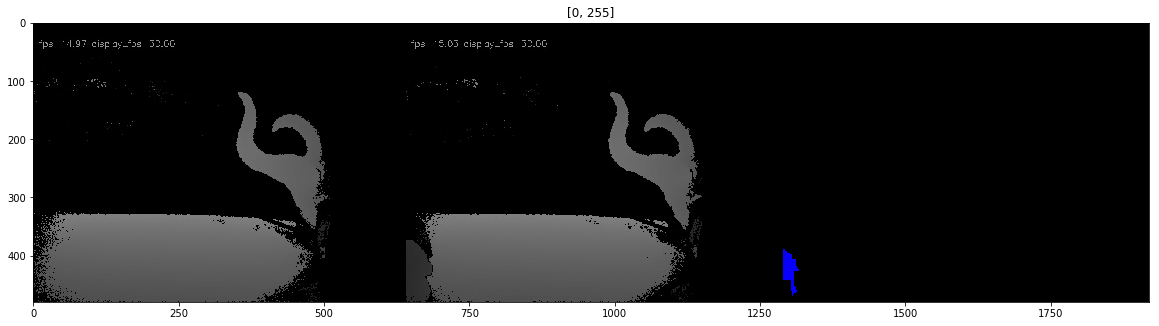

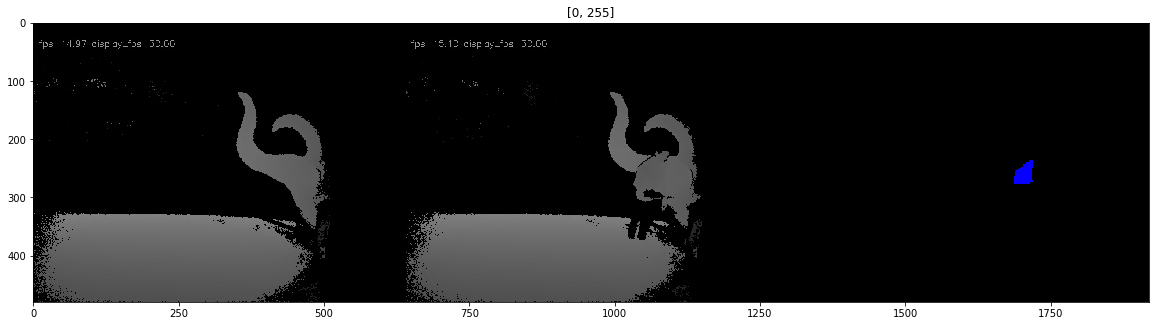

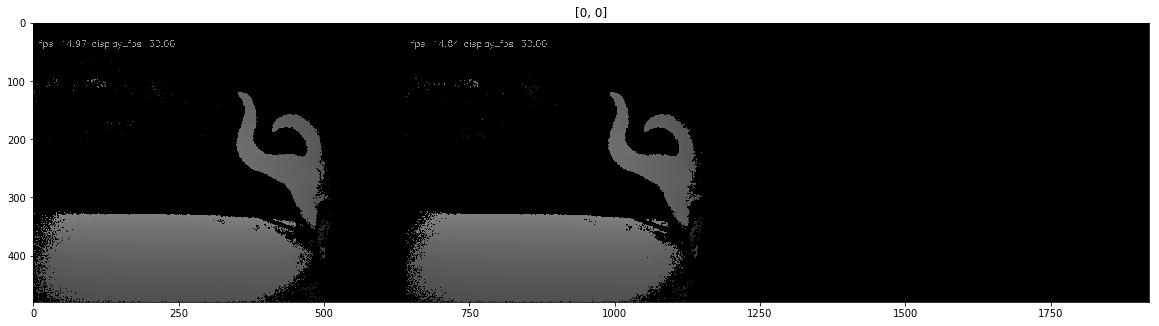

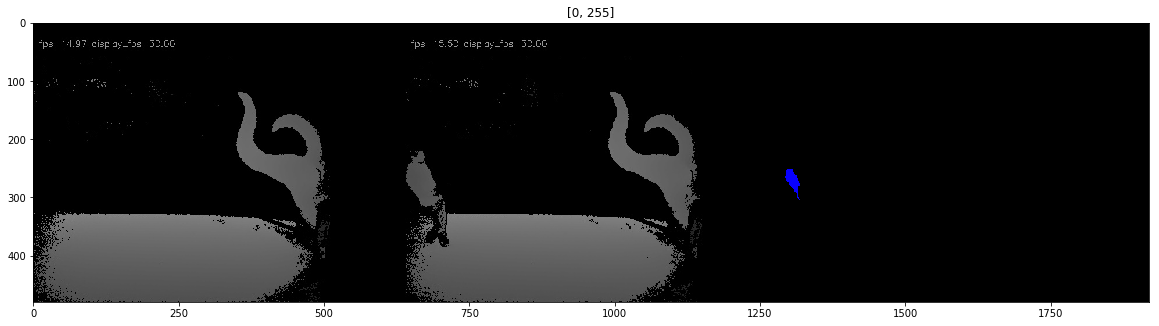

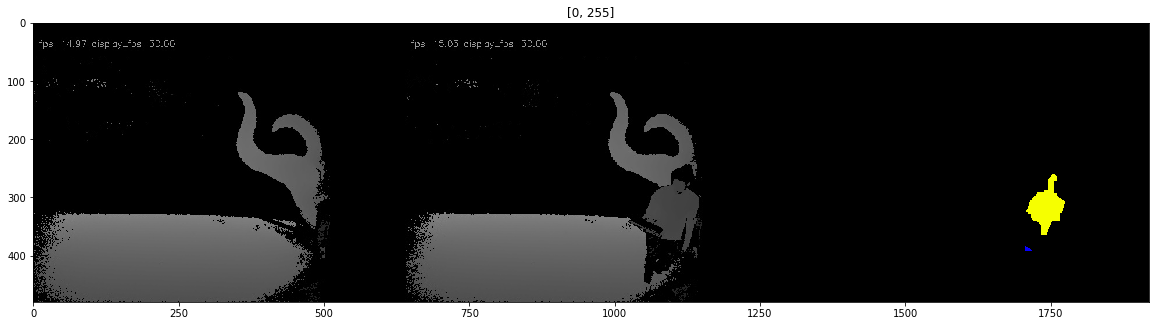

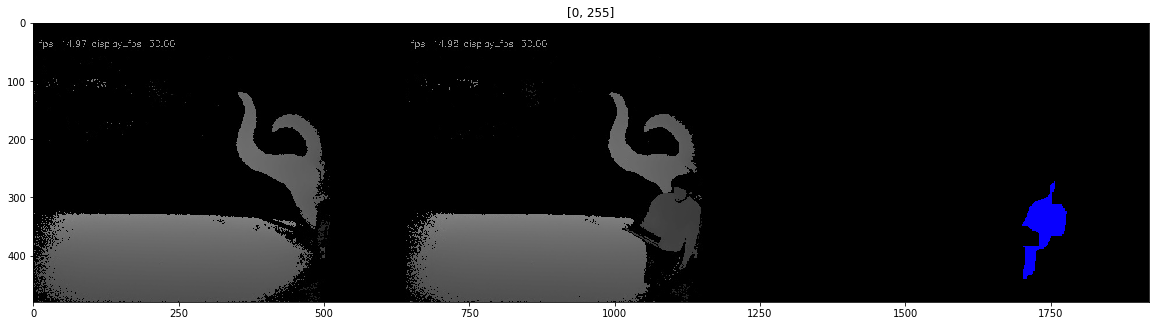

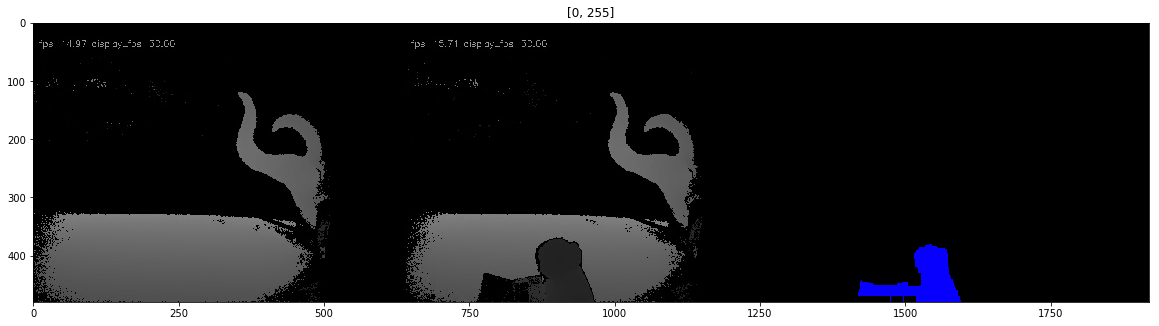

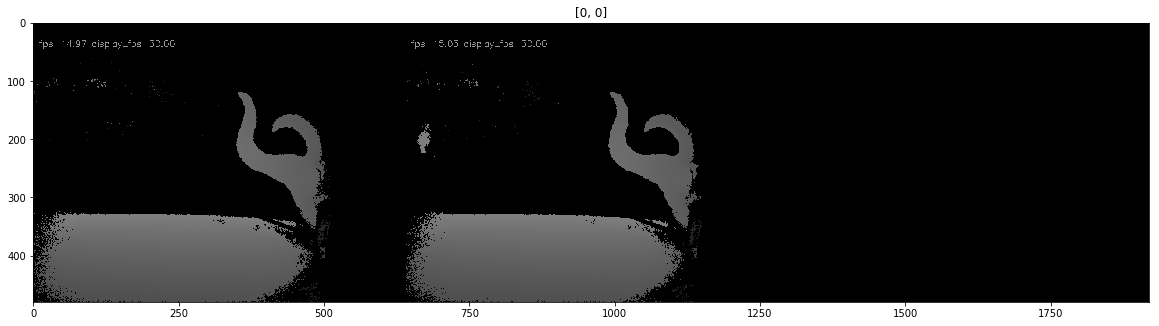

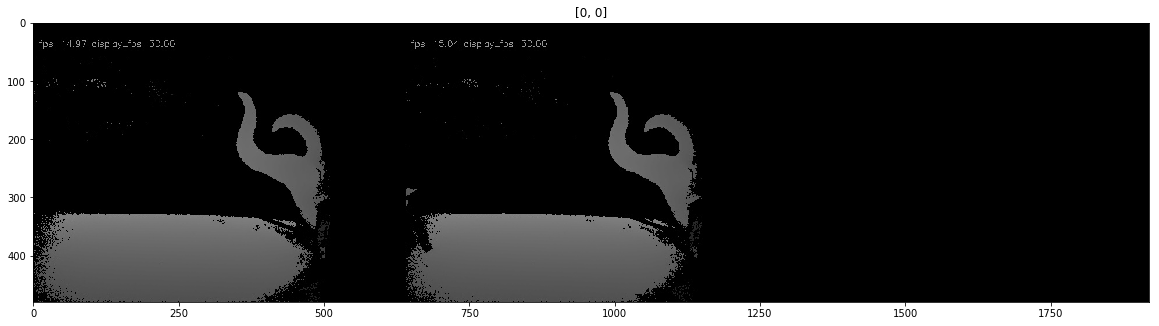

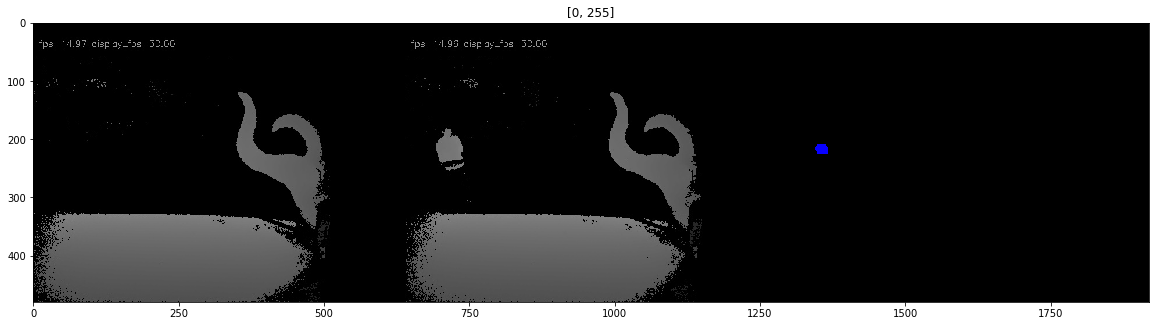

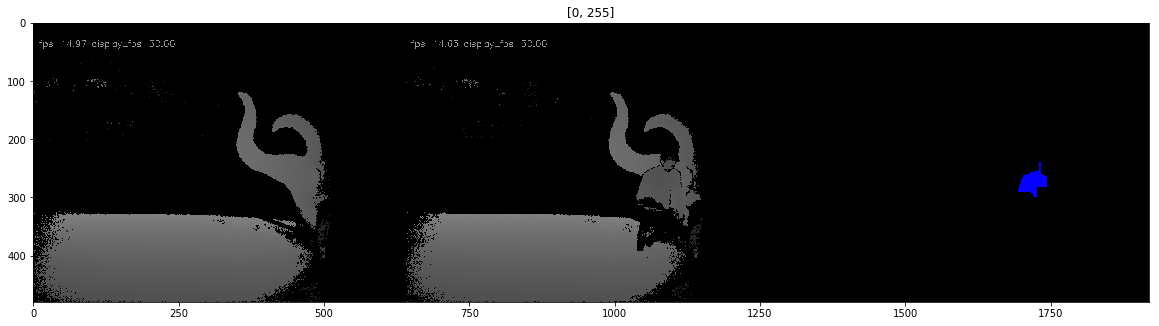

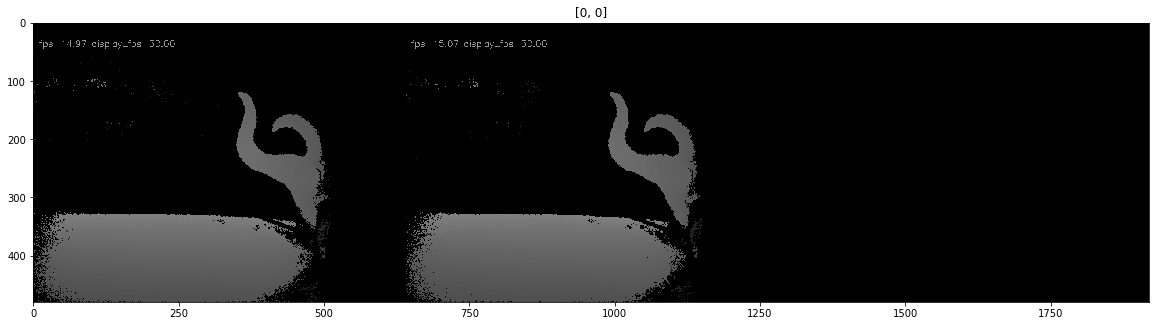

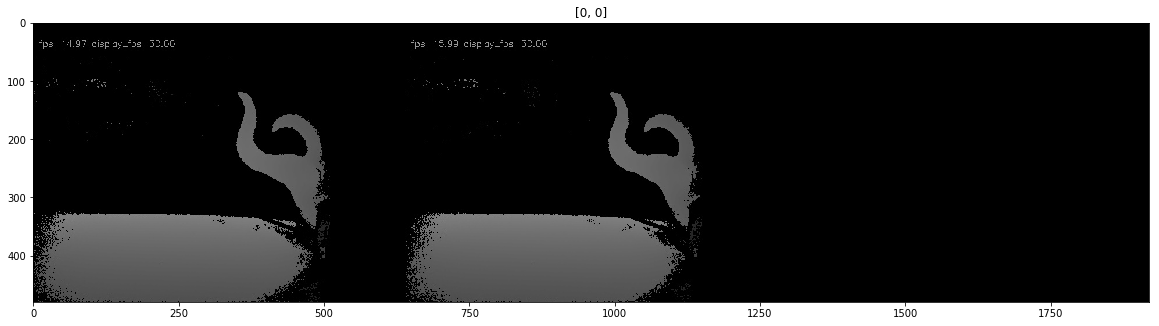

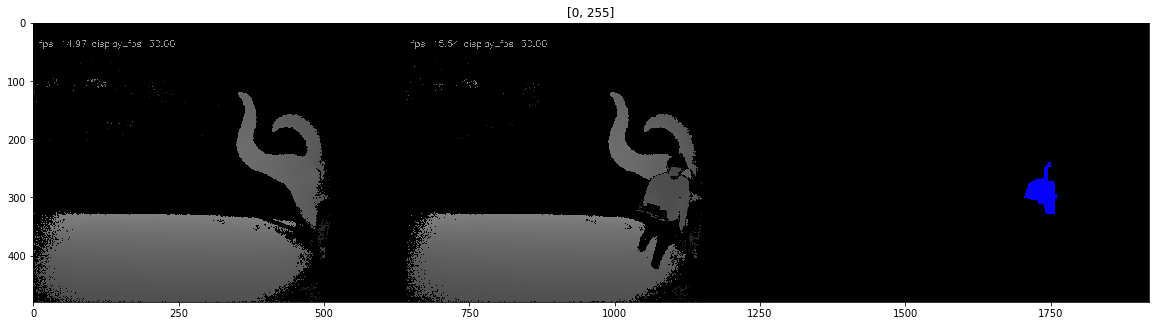

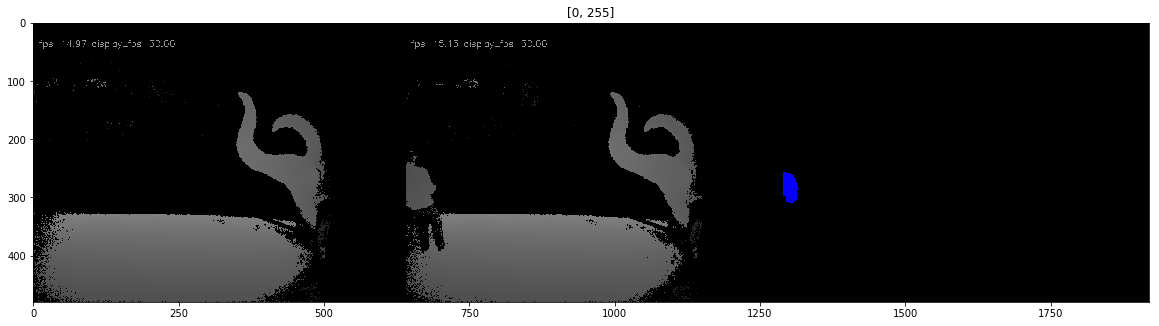

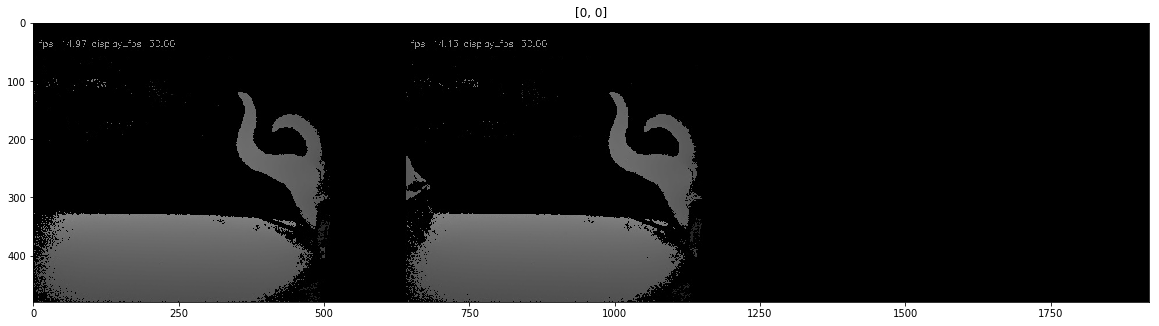

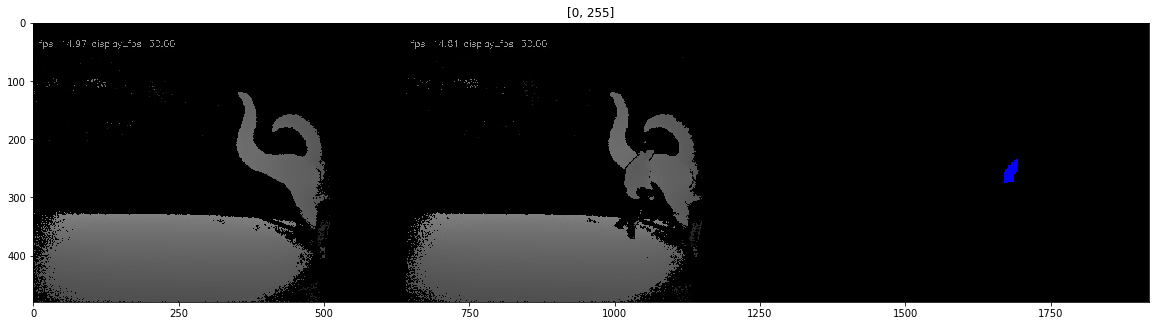

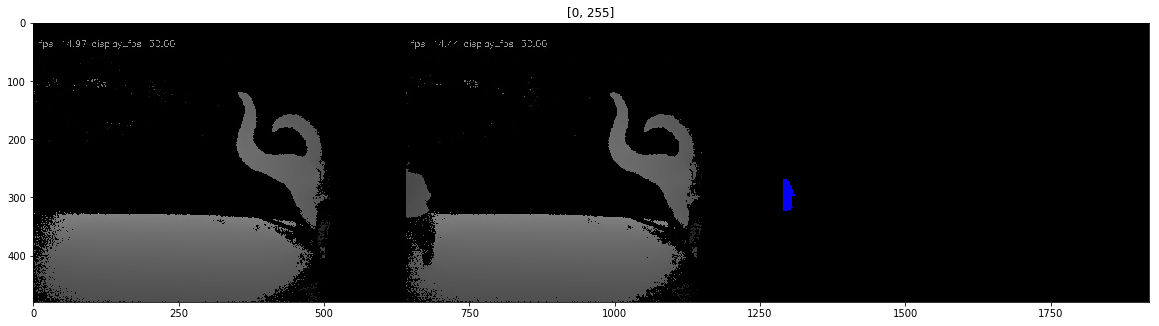

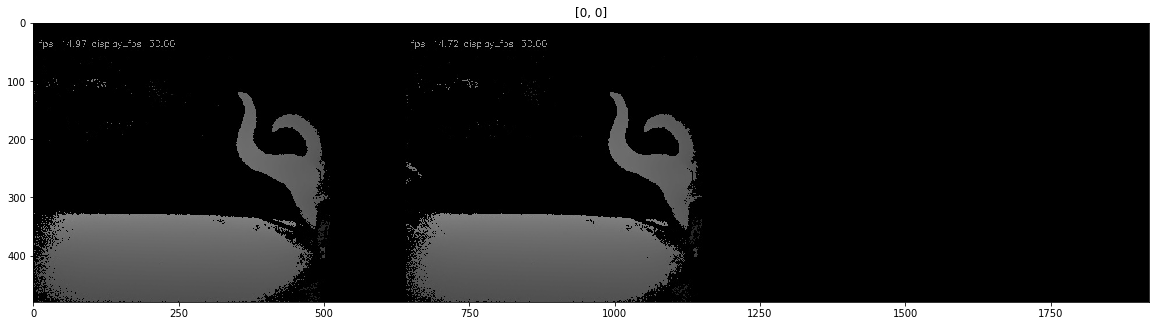

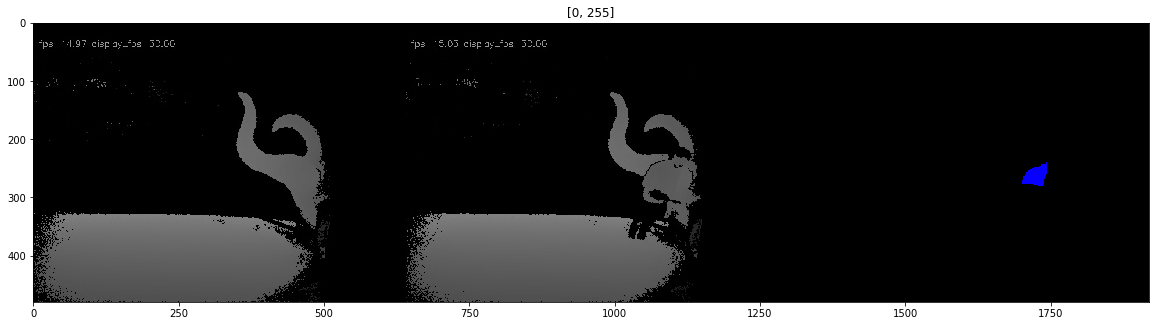

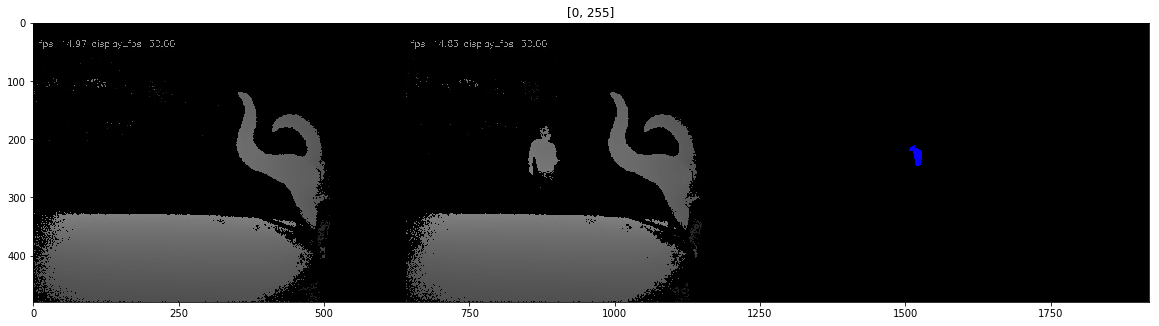

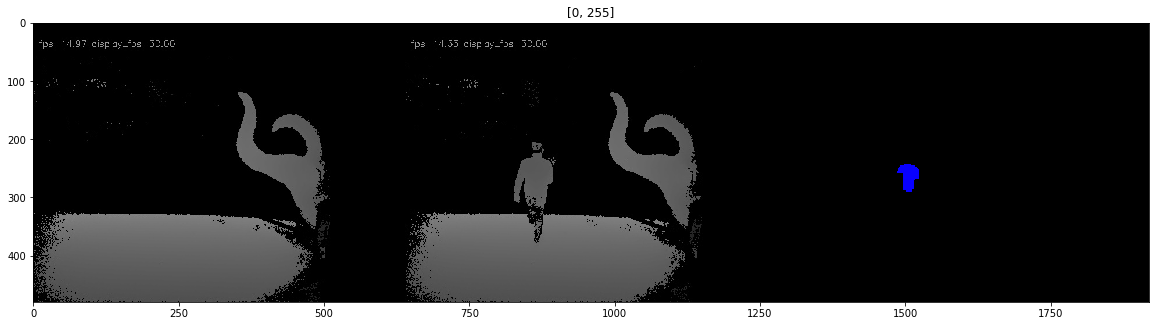

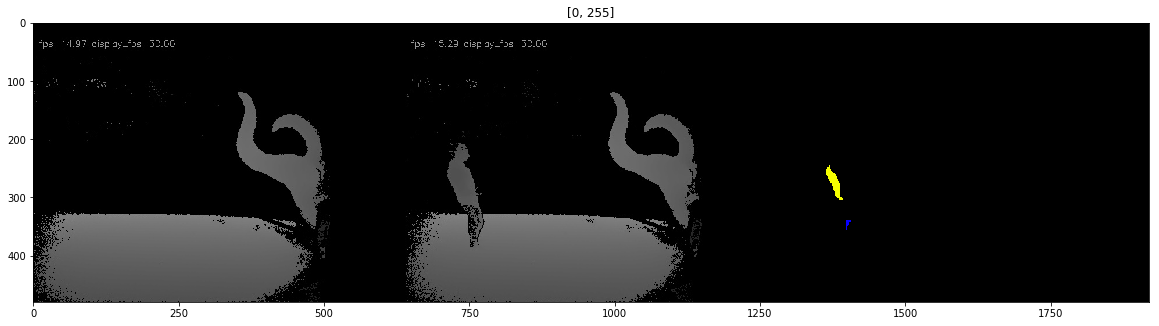

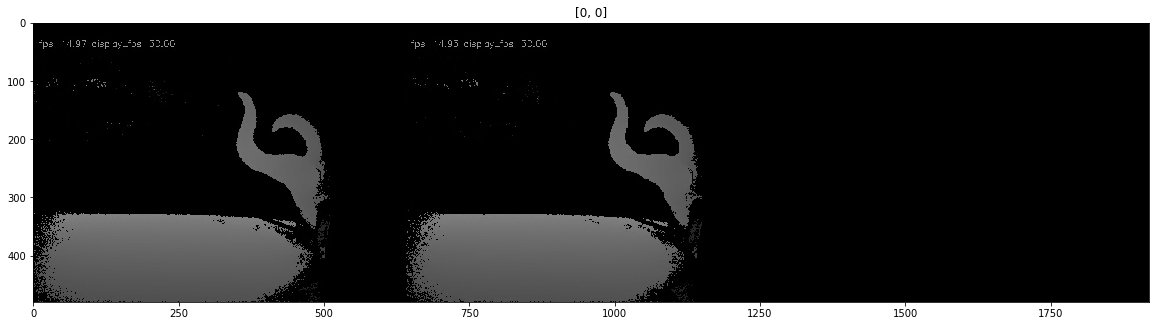

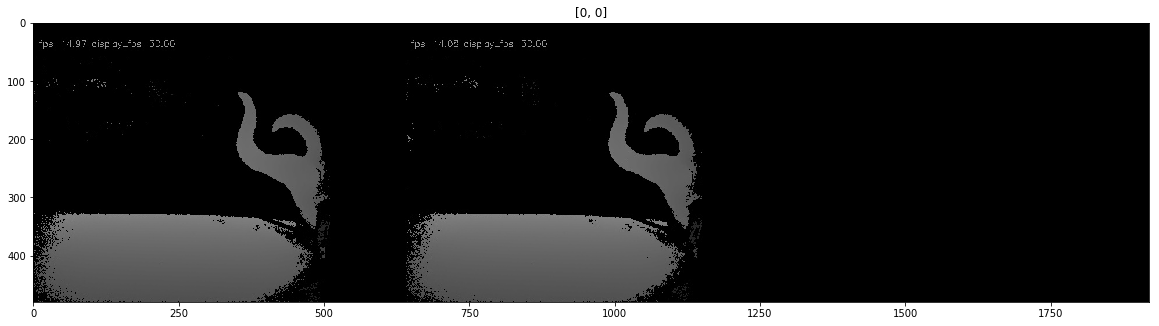

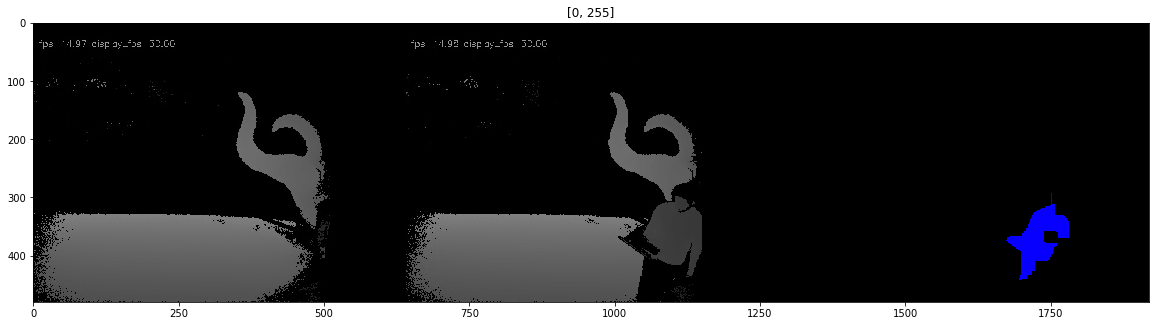

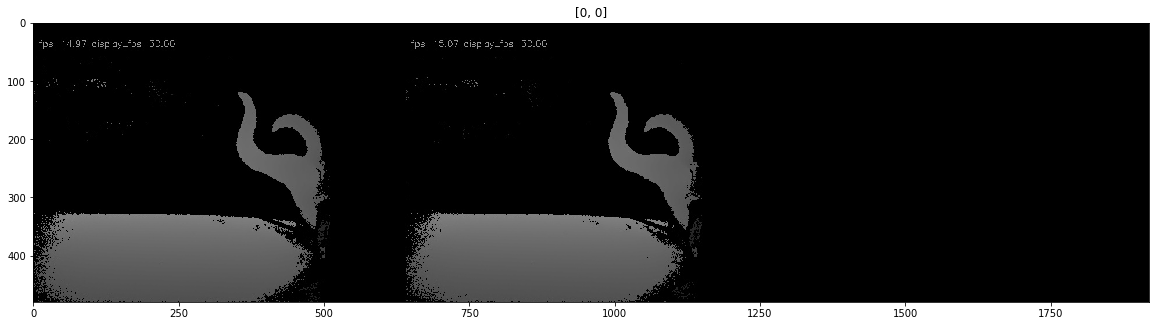

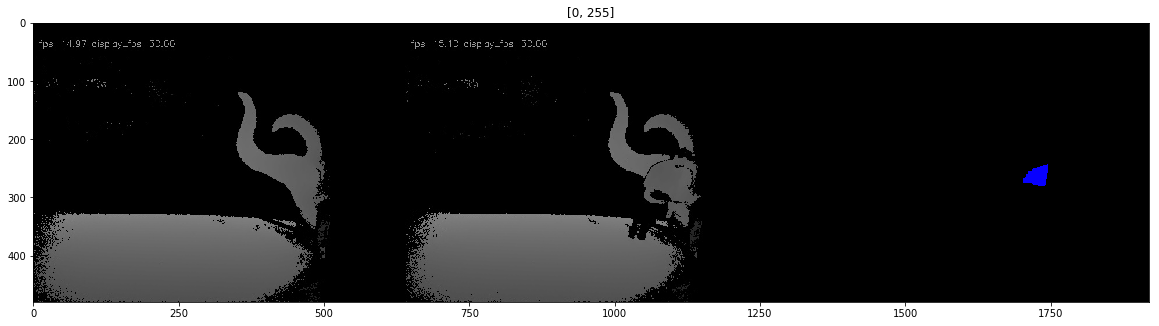

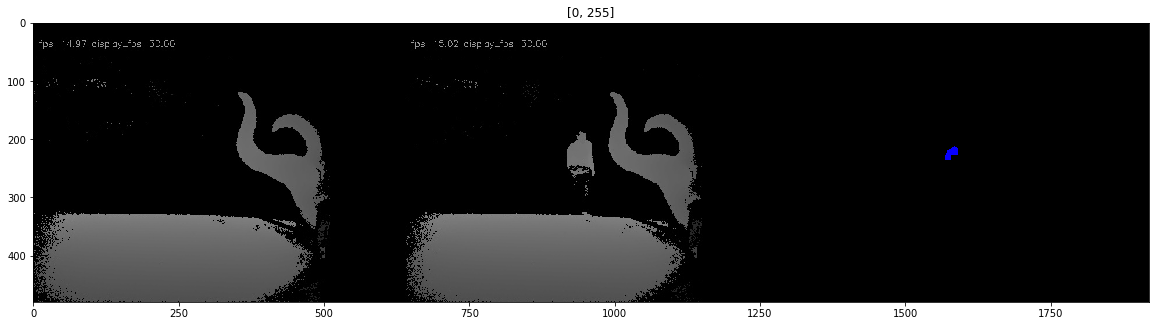

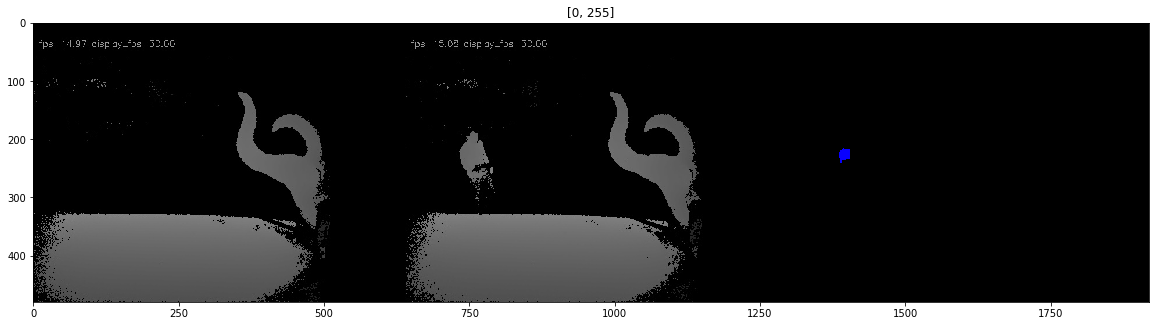

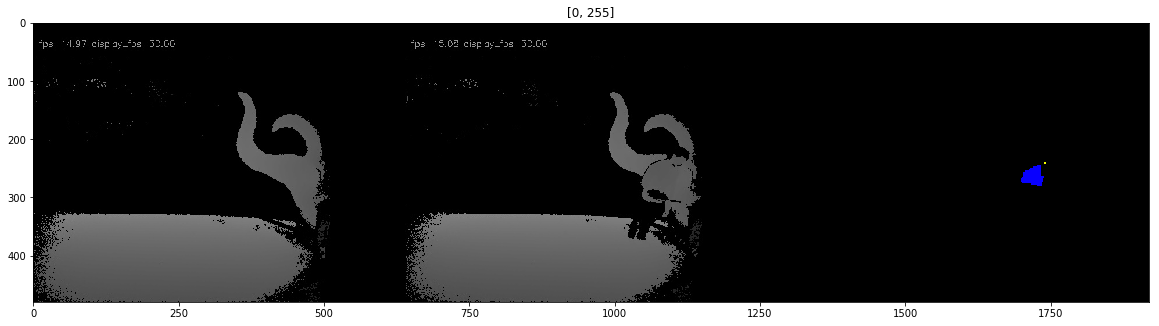

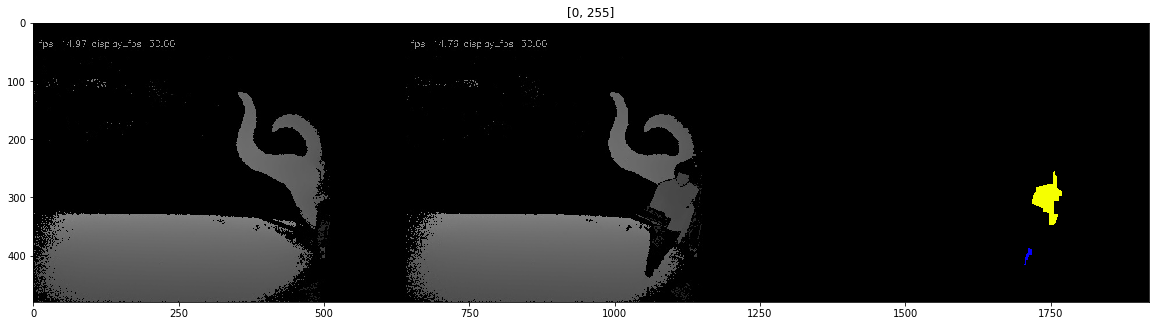

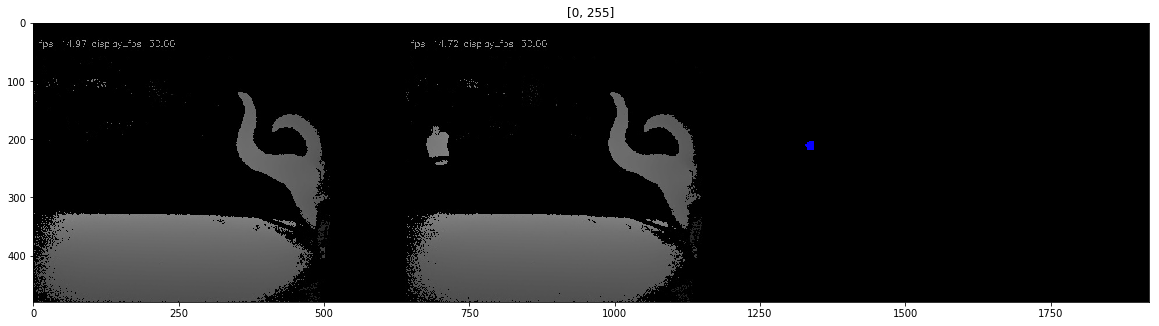

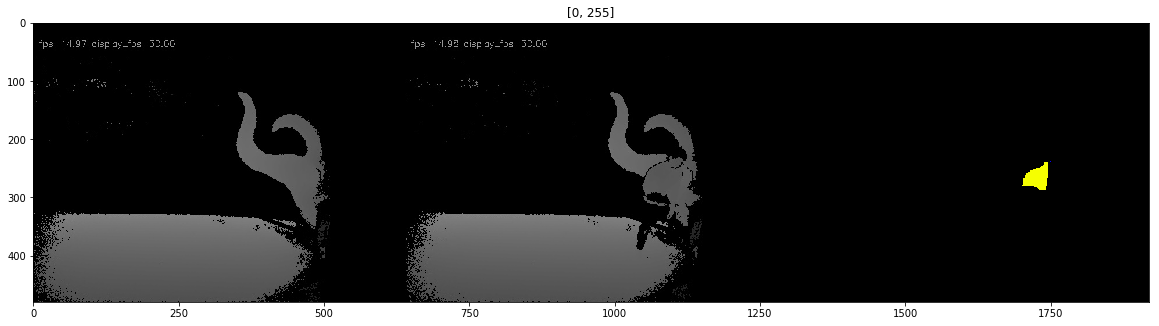

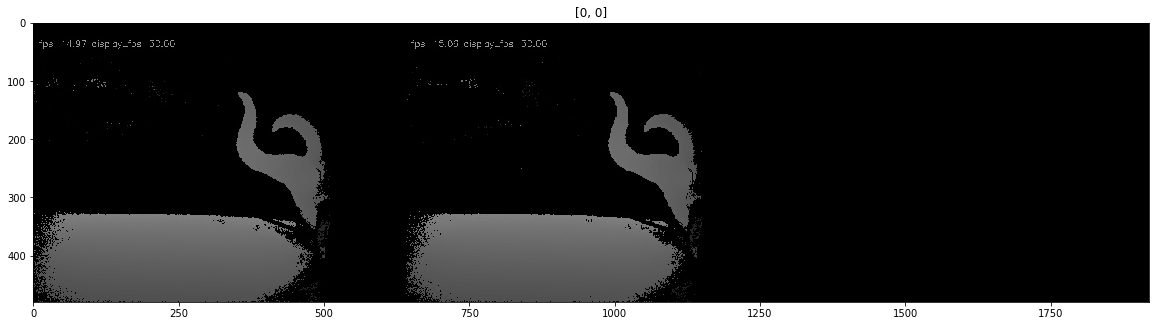

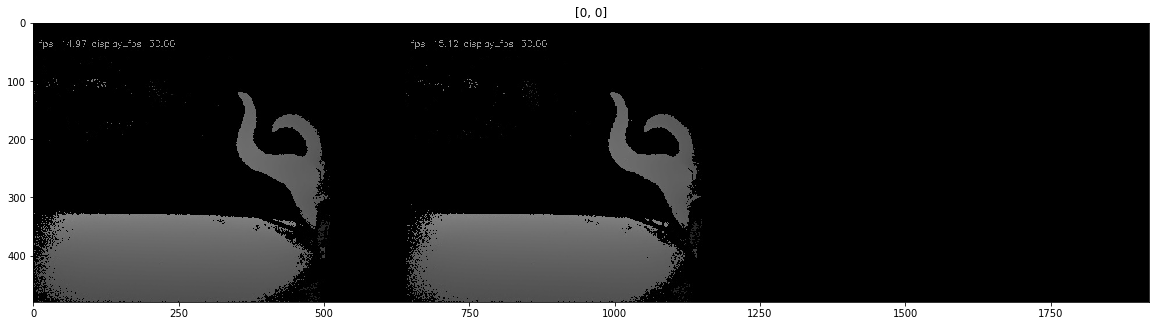

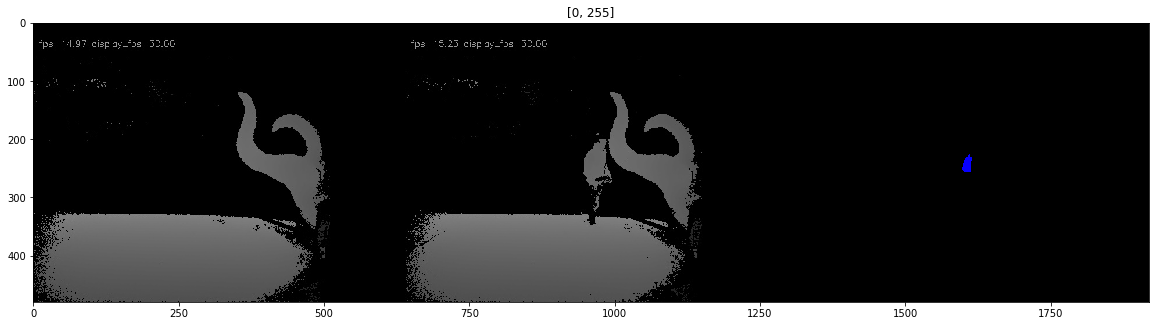

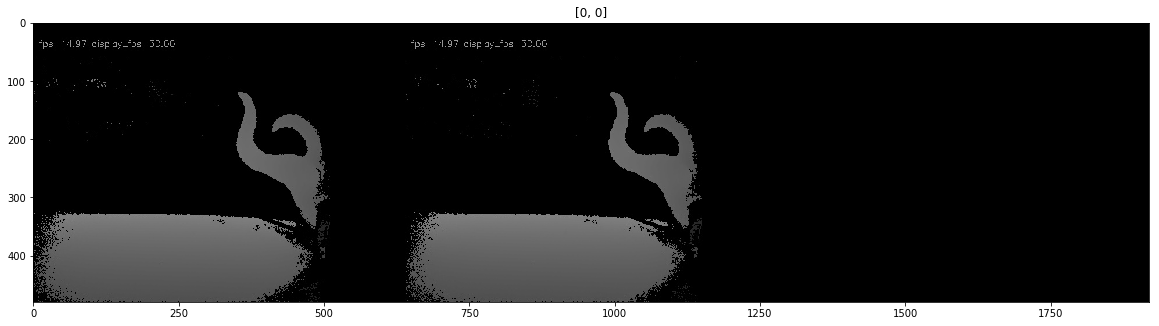

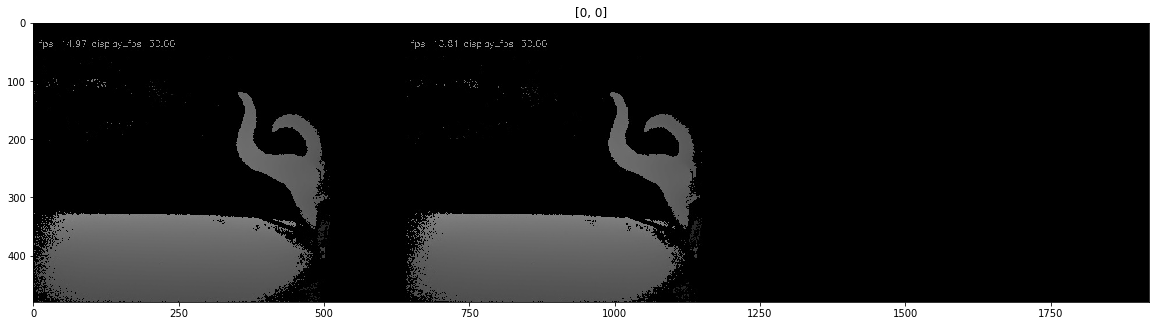

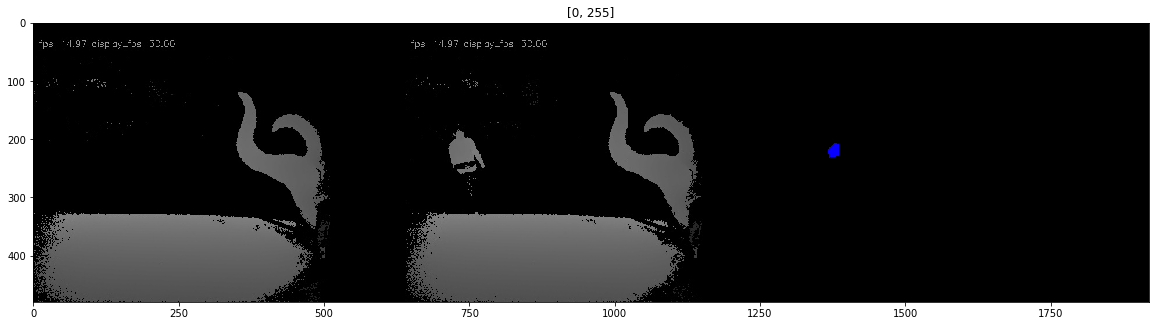

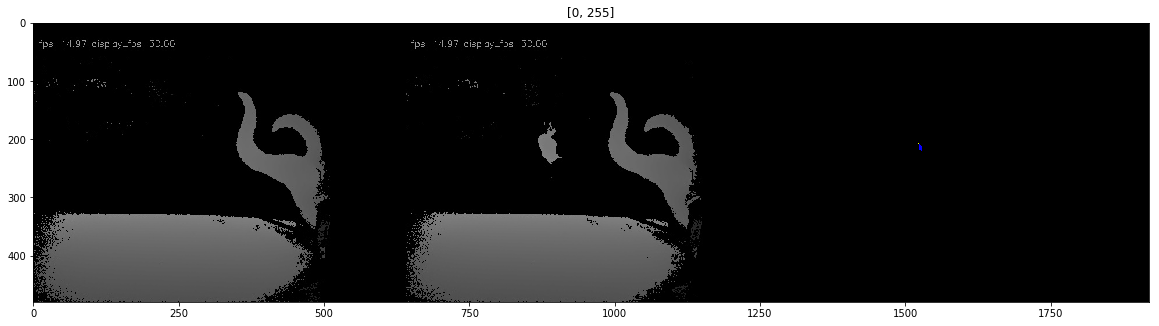

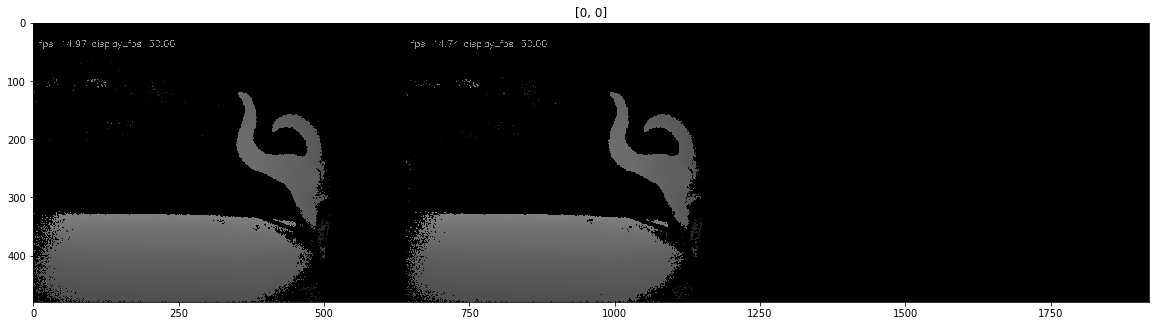

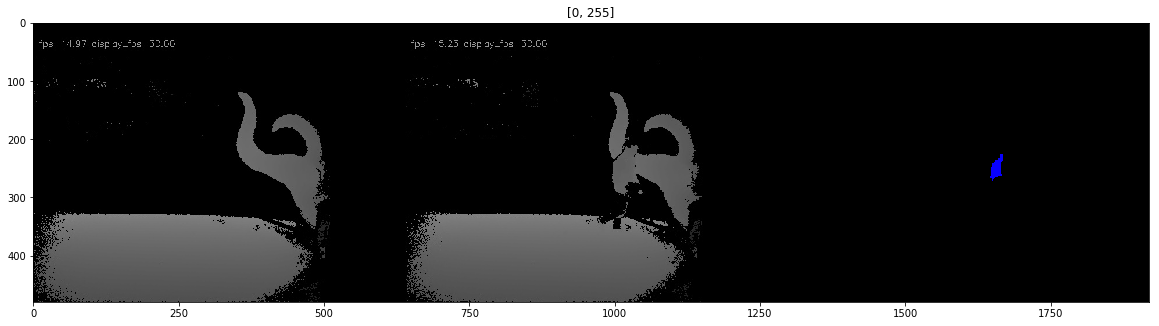

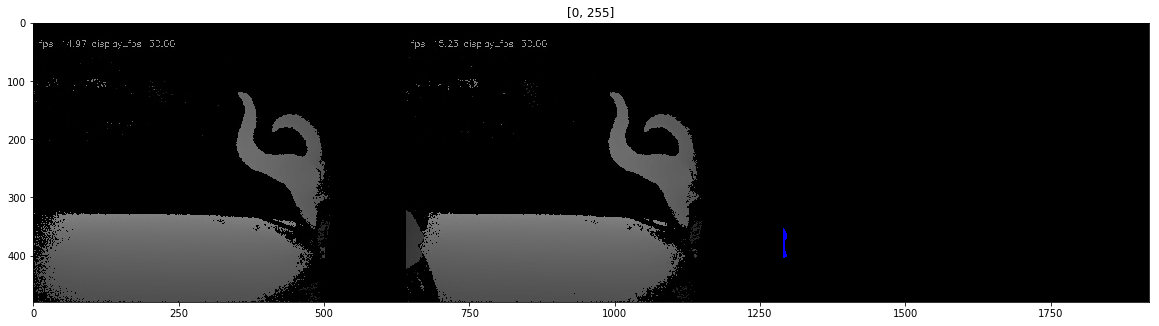

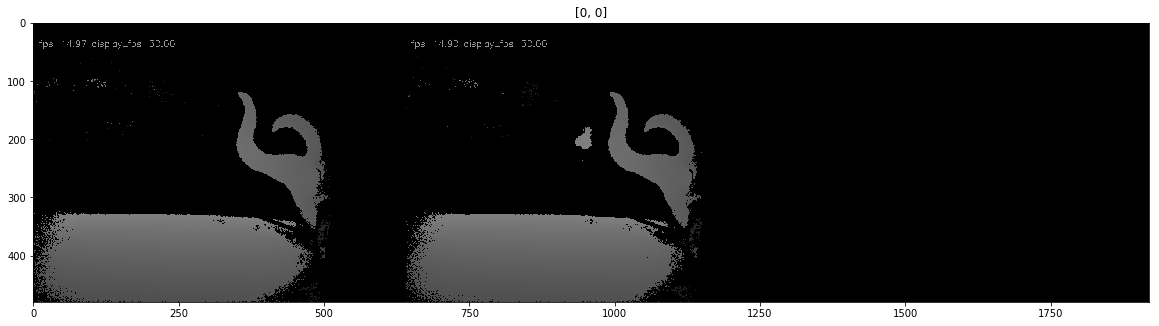

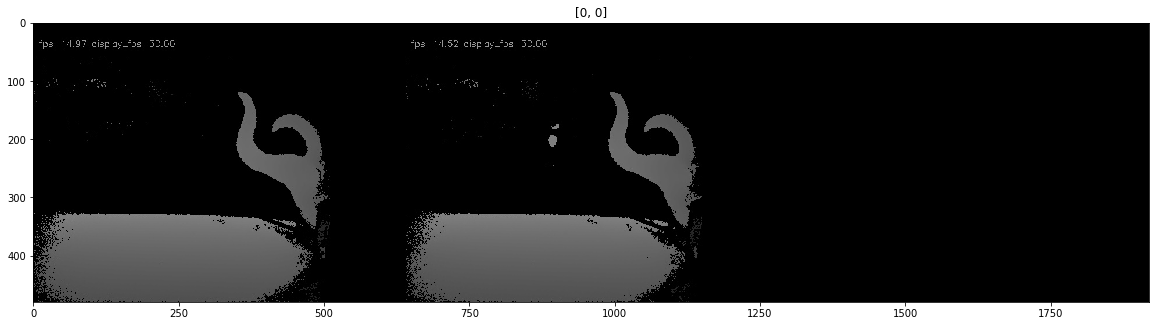

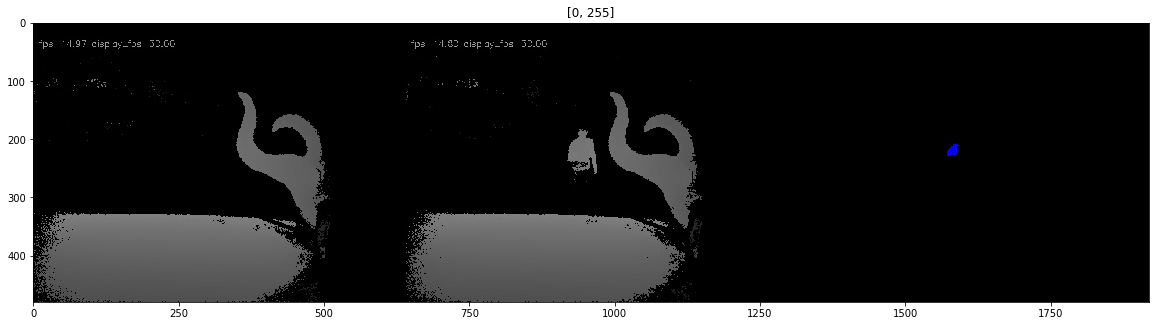

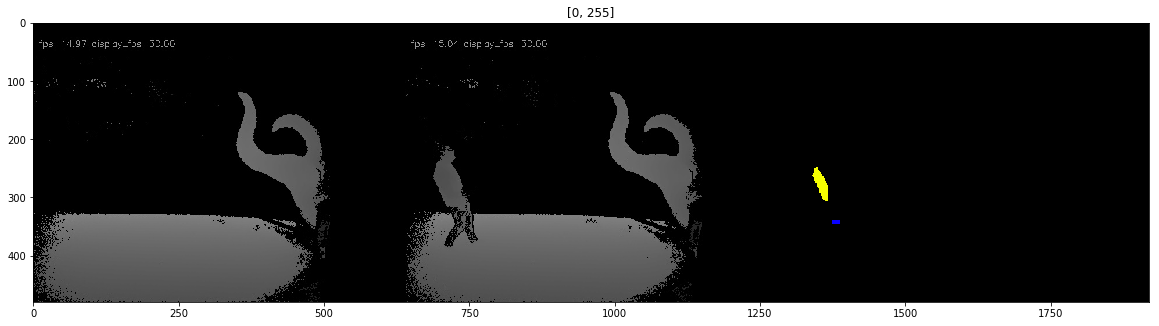

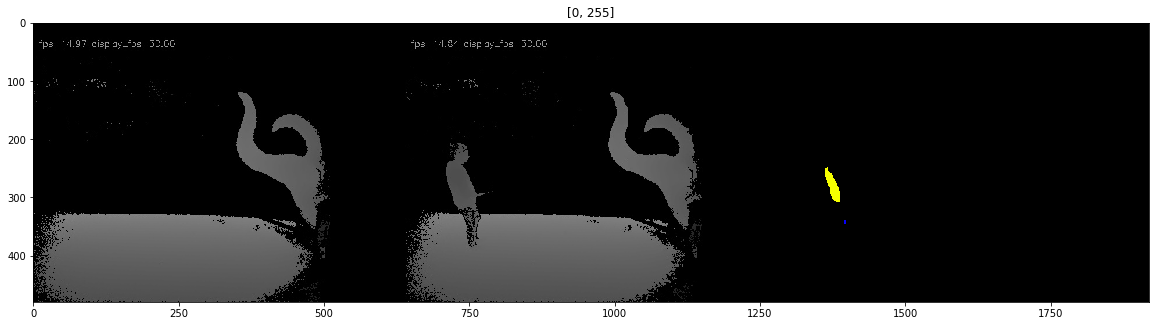

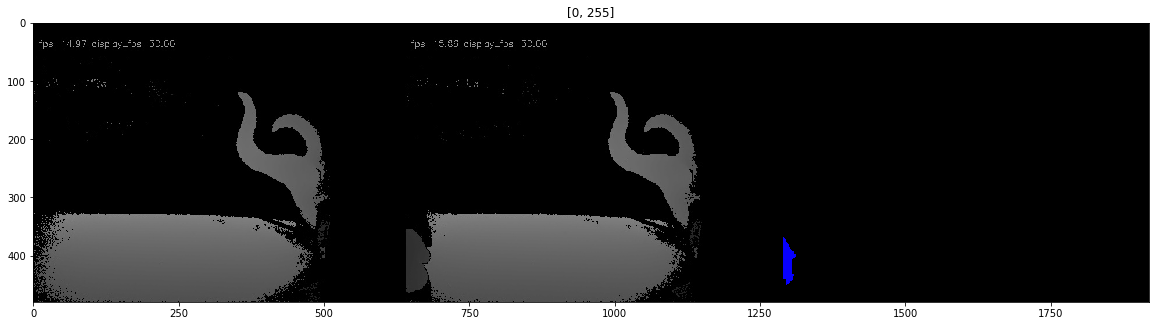

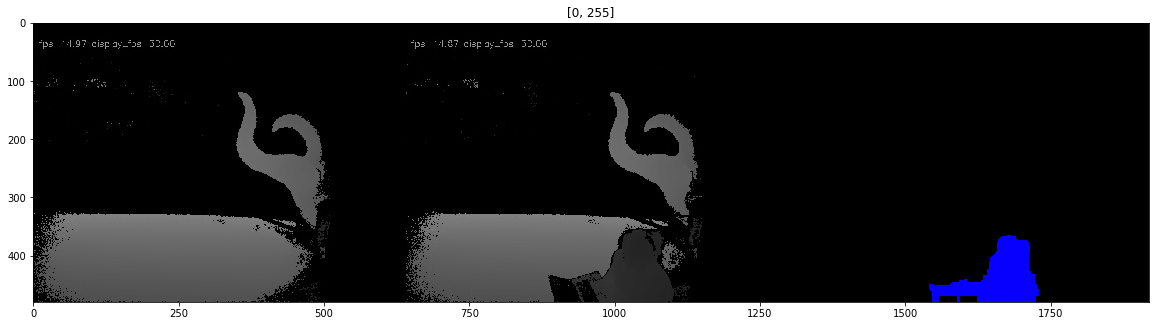

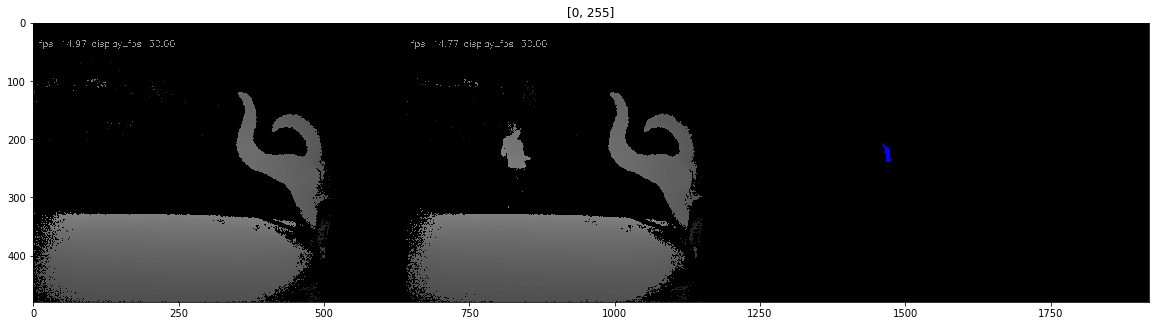

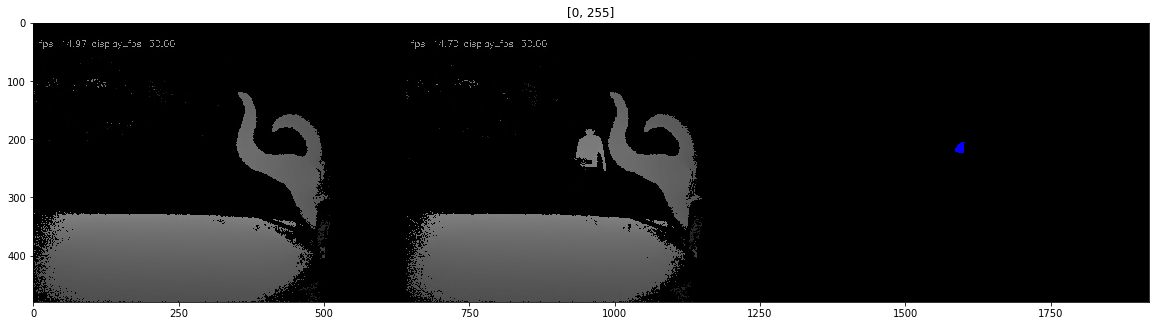

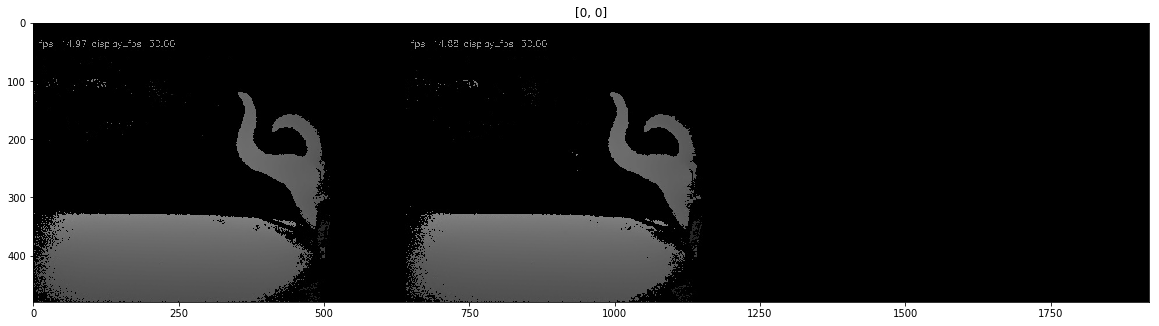

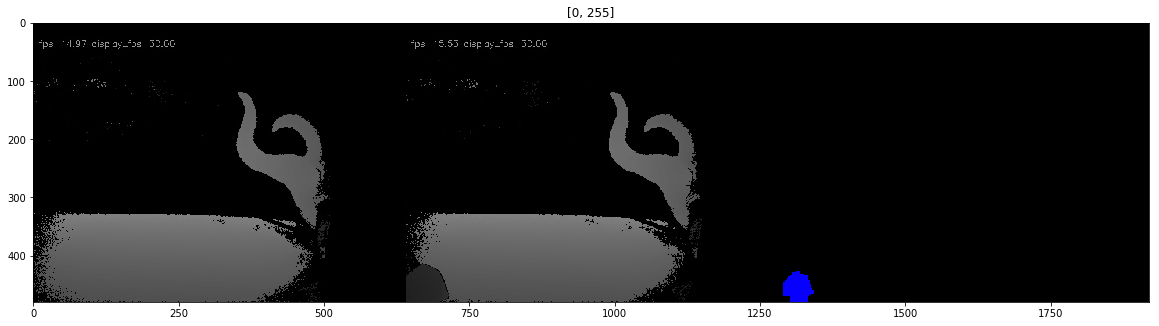

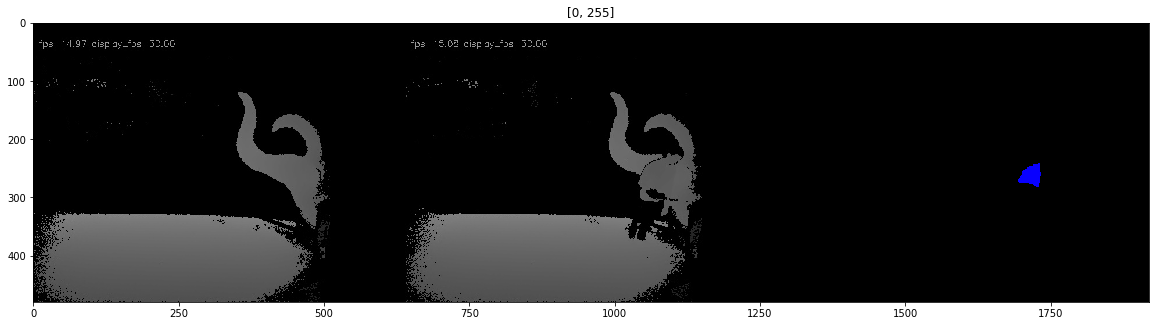

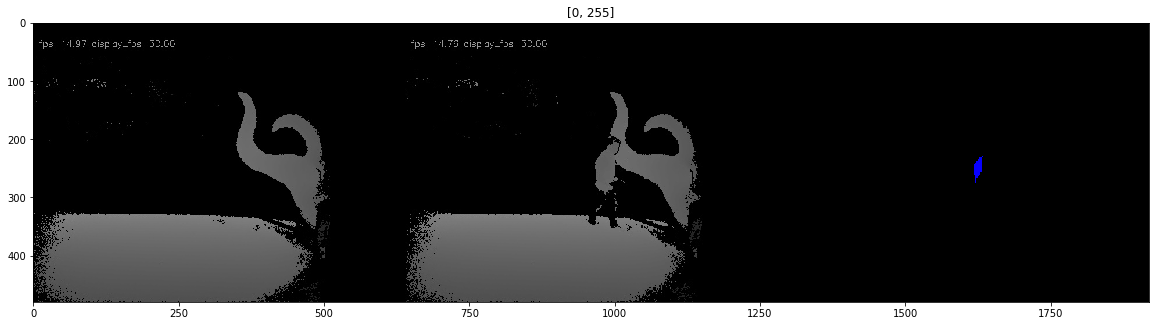

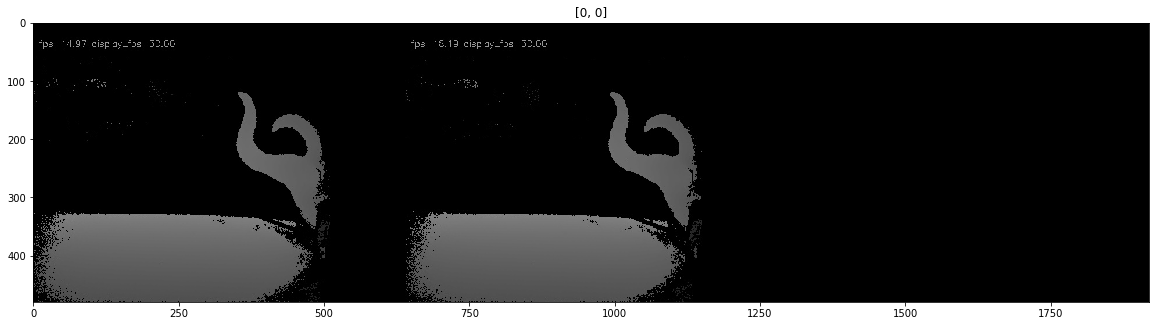

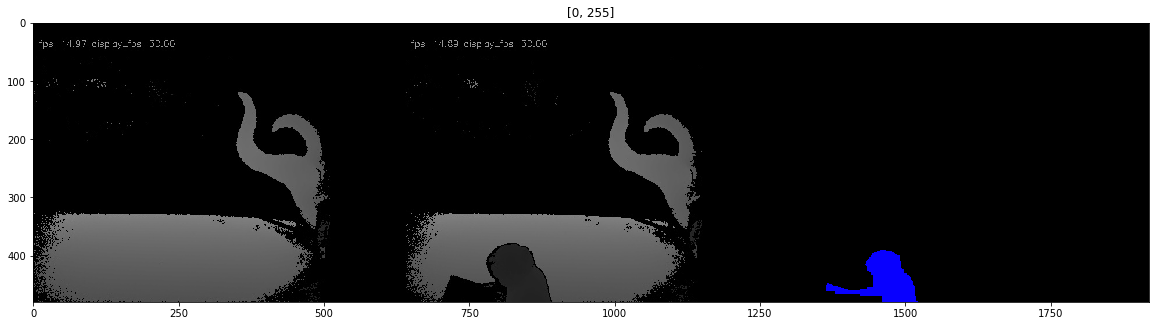

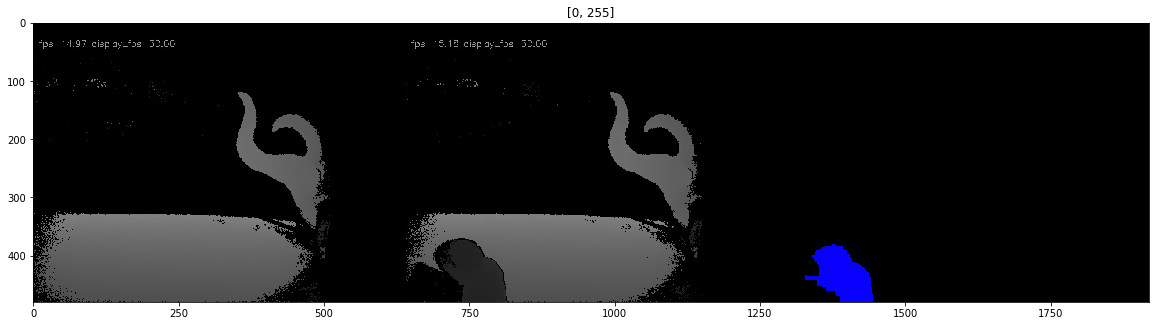

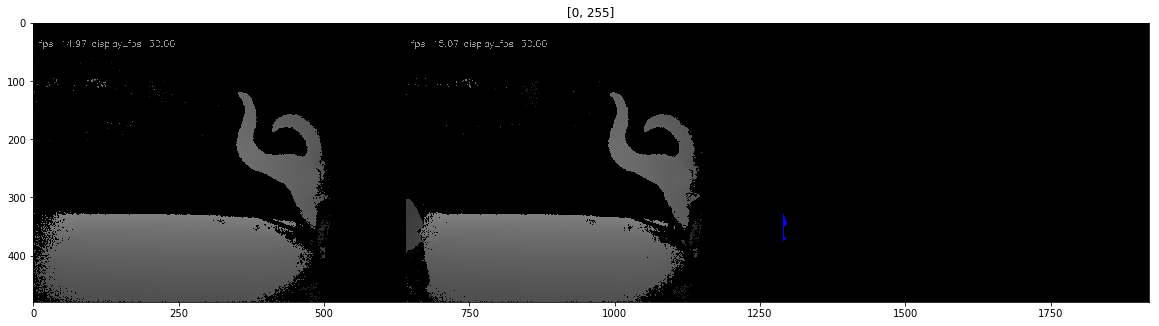

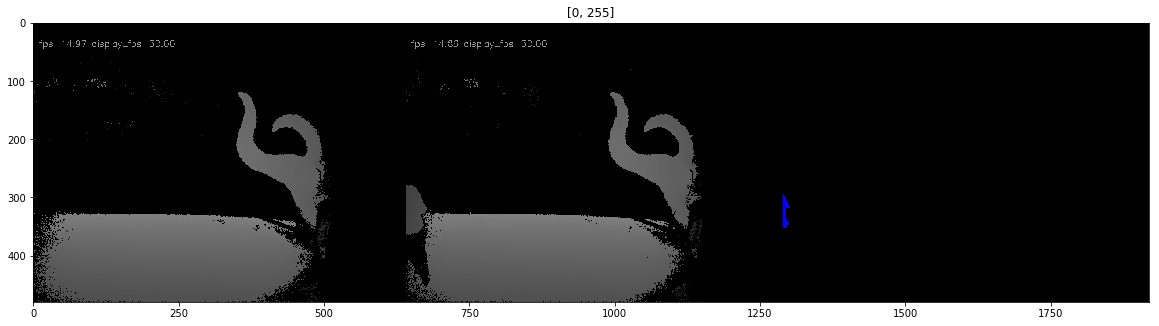

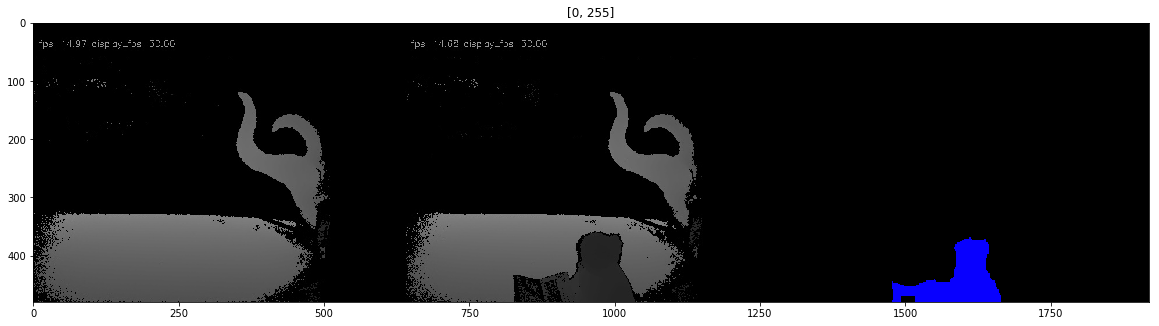

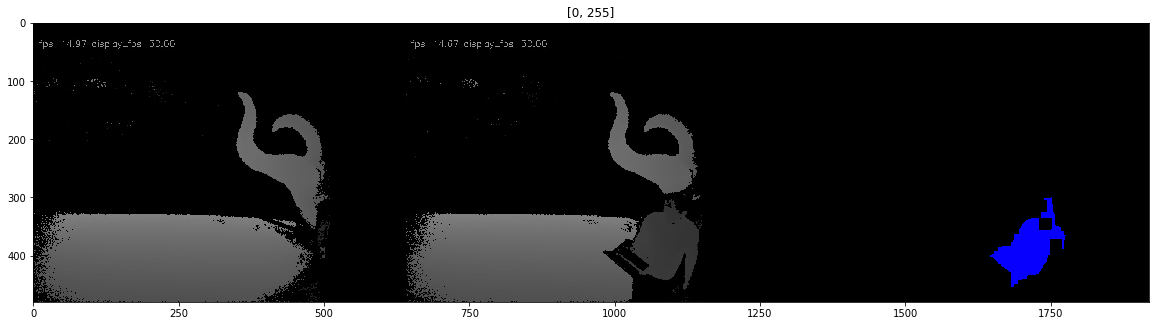

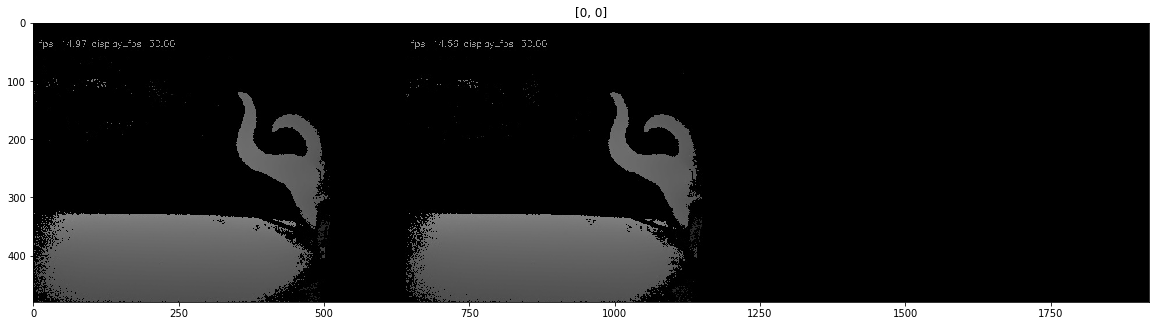

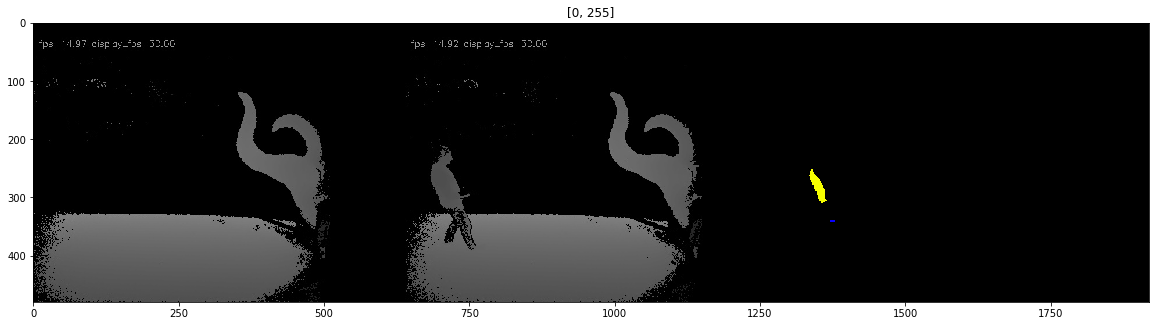

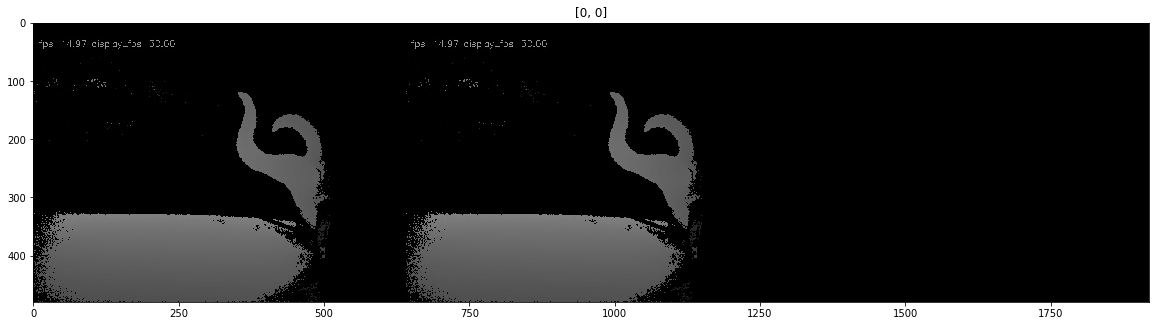

In [115]:
for idx, img in enumerate(imgs):
    if idx < 12:
        continue

    diff_img = adjust_gamma(diff_imgs[idx].astype("uint8"), 1)
    plt.imshow(np.hstack([cv2.cvtColor(ref_frame, cv2.COLOR_GRAY2RGB), cv2.cvtColor(img, cv2.COLOR_GRAY2RGB), diff_img]))
    plt.title(str([np.min(diff_img), np.max(diff_img)]))
    plt.show()